# Step-by-Step Percentile Optimization (Manual Multi-Item Example)

This walkthrough manually builds data for **5 unique items**, each with unique numeric
characteristics, using:

- **80 days history** (backtest period)
- **14 days replenishment period** (evaluation period)
- **Percentile candidates every 5%** with multipliers around the mean forecast

The goal is to make every controllable parameter explicit so you can see how policy
tuning behaves, one SKU at a time.

**Scope note (Task 14 rewrite):** this notebook is rewritten against the new
strategy-composed API. Percentile forecasts already embed their own buffer, so each
candidate policy uses `NullSafetyStockStrategy()` -- no old `PercentileForecastOptimizationPolicy`
class needed. Cost per candidate is computed with a direct `simulate_replenishment` loop
(janrth's `evaluate_forecast_target_costs`/`optimize_forecast_targets` batch helpers were
never ported; see `io_.py`'s module docstring).

## 1) Imports and reproducibility

In [1]:
from __future__ import annotations

from dataclasses import replace
from datetime import date, timedelta
import random

import matplotlib.pyplot as plt
import pandas as pd

from replenishment.io_ import (
    StandardSimulationRow, ReplenishmentDecisionRow, split_standard_simulation_rows,
    standard_simulation_rows_to_dataframe, replenishment_decision_rows_to_dataframe,
)
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.multiplier import NullSafetyStockStrategy
from replenishment.strategies.order_trigger import OrderUpToTrigger, ReorderPointTrigger
from replenishment.viz import plot_replenishment_decisions

## 2) Global configuration (all explicit)

In [2]:
START_DATE = date(2032, 1, 1)
FREQUENCY_DAYS = 1
HISTORY_DAYS = 80
REPLENISHMENT_DAYS = 14
TOTAL_DAYS = HISTORY_DAYS + REPLENISHMENT_DAYS
FORECAST_START_PERIOD = HISTORY_DAYS

# Policy cadence controls -- "order_up_to" or "reorder_point"
TRIGGER_MODE = "order_up_to"
REVIEW_PERIOD_DEFAULT = 3
FORECAST_HORIZON_DEFAULT = 3

# Randomness controls
SEED = 20260211
rng = random.Random(SEED)

# Percentile grid controls: every 5% from p05 to p95
PERCENTILE_STEP = 5
PERCENTILE_LEVELS = list(range(5, 100, PERCENTILE_STEP))
MULTIPLIER_AT_P05 = 0.55
MULTIPLIER_AT_P95 = 1.45

def multiplier_from_percentile(percentile: int) -> float:
    span = (MULTIPLIER_AT_P95 - MULTIPLIER_AT_P05) / (95 - 5)
    return round(MULTIPLIER_AT_P05 + (percentile - 5) * span, 3)

def percentile_label(percentile: int) -> str:
    return f"p{percentile:02d}"

PERCENTILE_MULTIPLIERS = {percentile_label(p): multiplier_from_percentile(p) for p in PERCENTILE_LEVELS}
CANDIDATE_TARGETS = list(PERCENTILE_MULTIPLIERS.keys()) + ["mean"]

## 3) Manual item-level setup (5 unique IDs with unique numeric characteristics)

In [3]:
ITEM_CONFIG = {
    "SKU_A": {
        "holding_cost_per_unit": 0.35, "stockout_cost_per_unit": 11.0, "order_cost_per_order": 11.0,
        "lead_time": 1, "review_period": 3, "forecast_horizon": 3, "initial_on_hand": 32, "current_stock": 29,
        "history_base": 20.0, "history_trend": 0.10, "history_noise_std": 1.8,
        "forecast_base": 21.0, "forecast_trend": 0.12, "forecast_noise_std": 1.4, "future_actual_noise_std": 2.0,
    },
    "SKU_B": {
        "holding_cost_per_unit": 0.60, "stockout_cost_per_unit": 6.0, "order_cost_per_order": 8.0,
        "lead_time": 2, "review_period": 3, "forecast_horizon": 3, "initial_on_hand": 26, "current_stock": 21,
        "history_base": 16.0, "history_trend": 0.05, "history_noise_std": 2.4,
        "forecast_base": 15.0, "forecast_trend": 0.04, "forecast_noise_std": 1.8, "future_actual_noise_std": 2.6,
    },
    "SKU_C": {
        "holding_cost_per_unit": 0.45, "stockout_cost_per_unit": 14.0, "order_cost_per_order": 9.5,
        "lead_time": 3, "review_period": 2, "forecast_horizon": 2, "initial_on_hand": 40, "current_stock": 33,
        "history_base": 28.0, "history_trend": -0.05, "history_noise_std": 3.1,
        "forecast_base": 27.0, "forecast_trend": -0.03, "forecast_noise_std": 2.2, "future_actual_noise_std": 3.3,
    },
    "SKU_D": {
        "holding_cost_per_unit": 0.25, "stockout_cost_per_unit": 20.0, "order_cost_per_order": 6.0,
        "lead_time": 1, "review_period": 1, "forecast_horizon": 1, "initial_on_hand": 18, "current_stock": 15,
        "history_base": 9.0, "history_trend": 0.08, "history_noise_std": 1.1,
        "forecast_base": 9.5, "forecast_trend": 0.09, "forecast_noise_std": 0.9, "future_actual_noise_std": 1.3,
    },
    "SKU_E": {
        "holding_cost_per_unit": 0.70, "stockout_cost_per_unit": 5.0, "order_cost_per_order": 13.0,
        "lead_time": 4, "review_period": 4, "forecast_horizon": 4, "initial_on_hand": 55, "current_stock": 48,
        "history_base": 34.0, "history_trend": 0.0, "history_noise_std": 4.0,
        "forecast_base": 33.0, "forecast_trend": 0.0, "forecast_noise_std": 3.2, "future_actual_noise_std": 4.4,
    },
}

## 4) Build rows manually

We create a small synthetic dataset by sampling history and forecast values for each SKU.
Each row is a `StandardSimulationRow`, which the replenishment helpers expect.

In [4]:
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

rows: list[StandardSimulationRow] = []
for unique_id, cfg in ITEM_CONFIG.items():
    for period in range(TOTAL_DAYS):
        ds = (START_DATE + timedelta(days=period * FREQUENCY_DAYS)).isoformat()
        is_forecast = period >= FORECAST_START_PERIOD

        history_mean = cfg["history_base"] + cfg["history_trend"] * period
        forecast_mean = cfg["forecast_base"] + cfg["forecast_trend"] * period

        mean_forecast = _sample_int(forecast_mean, cfg["forecast_noise_std"])
        actuals = (
            _sample_int(forecast_mean, cfg["future_actual_noise_std"]) if is_forecast
            else _sample_int(history_mean, cfg["history_noise_std"])
        )
        forecast_percentiles = {
            label: max(0, int(round(mean_forecast * multiplier)))
            for label, multiplier in PERCENTILE_MULTIPLIERS.items()
        }
        rows.append(StandardSimulationRow(
            unique_id=unique_id, ds=ds, demand=actuals if not is_forecast else mean_forecast,
            forecast=mean_forecast, actuals=actuals if not is_forecast else None,
            holding_cost_per_unit=cfg["holding_cost_per_unit"], stockout_cost_per_unit=cfg["stockout_cost_per_unit"],
            order_cost_per_order=cfg["order_cost_per_order"], lead_time=cfg["lead_time"],
            initial_on_hand=cfg["initial_on_hand"], current_stock=cfg["current_stock"],
            forecast_percentiles=forecast_percentiles, is_forecast=is_forecast,
        ))

rows_df = standard_simulation_rows_to_dataframe(rows, library="pandas")
rows_df.groupby(["unique_id", "is_forecast"]).size().unstack()

is_forecast,False,True
unique_id,,
SKU_A,80,14
SKU_B,80,14
SKU_C,80,14
SKU_D,80,14
SKU_E,80,14


## 5) Plot original series

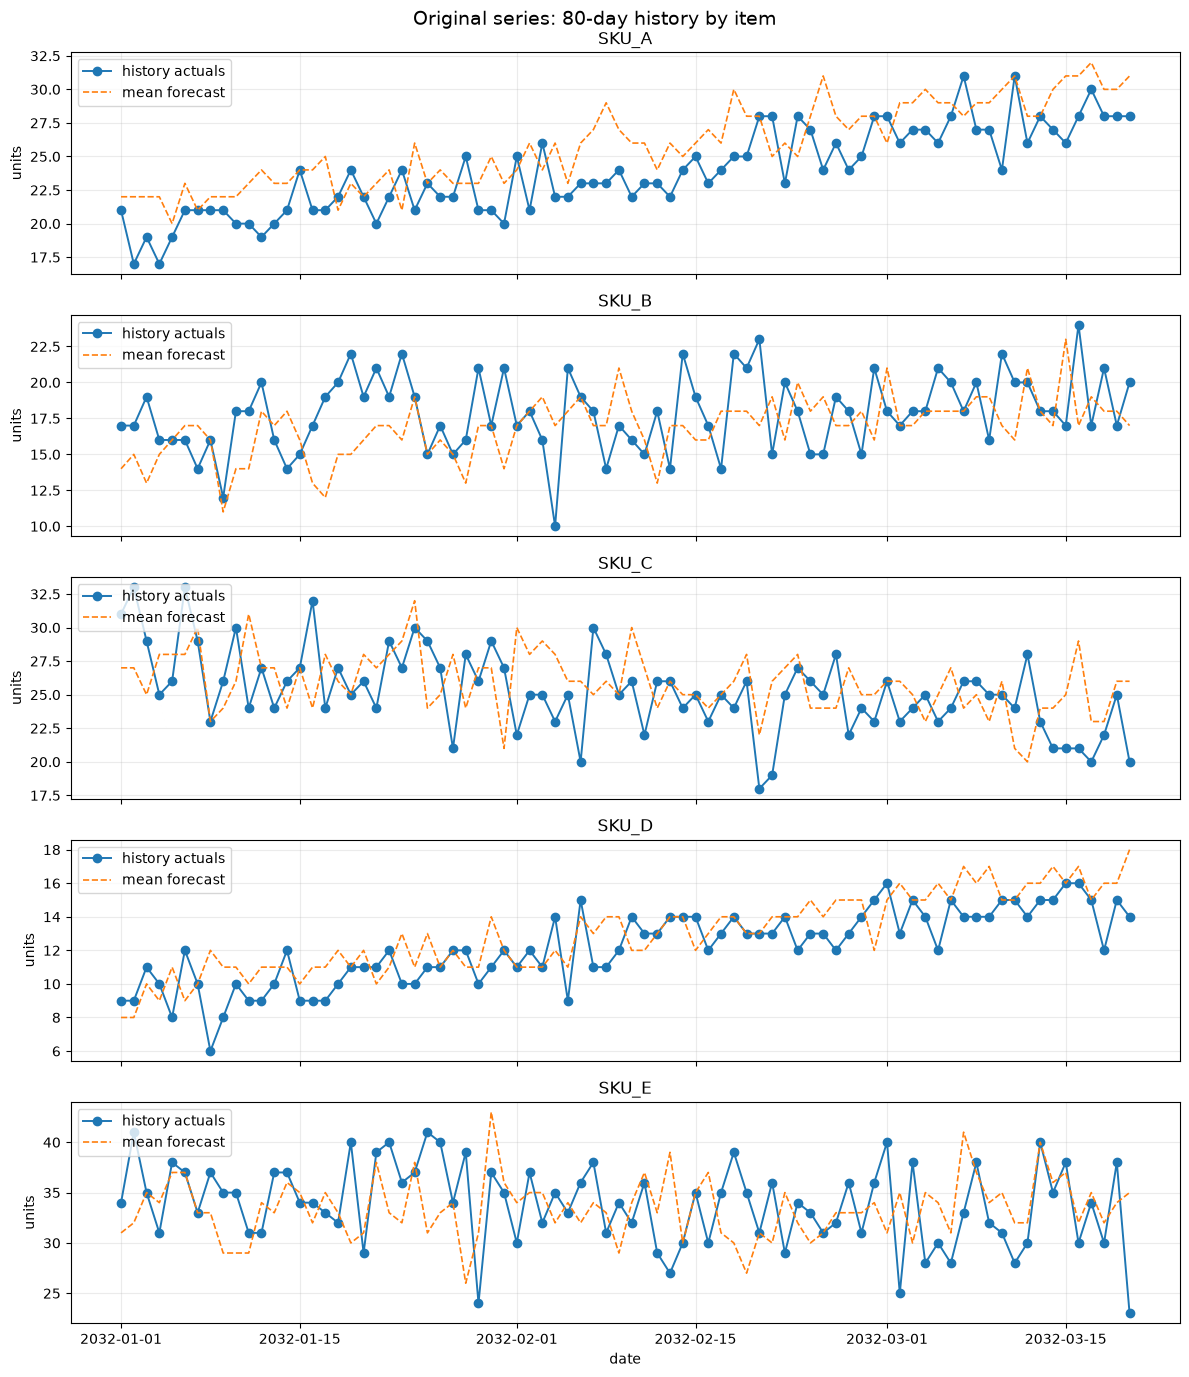

In [5]:
history_df = rows_df.loc[rows_df["is_forecast"] == False].copy()
history_df["ds"] = pd.to_datetime(history_df["ds"])

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 14), sharex=True)
for ax, unique_id in zip(axes, sorted(history_df["unique_id"].unique()), strict=False):
    d = history_df.loc[history_df["unique_id"] == unique_id].sort_values("ds")
    ax.plot(d["ds"], d["actuals"], marker="o", linewidth=1.4, label="history actuals")
    ax.plot(d["ds"], d["forecast"], linestyle="--", linewidth=1.2, label="mean forecast")
    ax.set_title(unique_id)
    ax.set_ylabel("units")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")

axes[-1].set_xlabel("date")
fig.suptitle("Original series: 80-day history by item", fontsize=14)
fig.tight_layout()
plt.show()

## 6) Split backtest (history) vs replenishment horizon

In [6]:
backtest_rows, forecast_rows = split_standard_simulation_rows(rows)
print(f"Backtest rows: {len(backtest_rows)}")
print(f"Forecast rows: {len(forecast_rows)}")

def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

backtest_by_article = _group_by_article(backtest_rows)
forecast_by_article = _group_by_article(forecast_rows)

# Add simulated actuals for the forecast/evaluation period (janrth's original also
# needs a realized outcome to evaluate against).
forecast_by_article = {
    uid: [replace(row, actuals=_sample_int(ITEM_CONFIG[uid]["forecast_base"], ITEM_CONFIG[uid]["future_actual_noise_std"]),
                  demand=_sample_int(ITEM_CONFIG[uid]["forecast_base"], ITEM_CONFIG[uid]["future_actual_noise_std"]))
          for row in article_rows]
    for uid, article_rows in forecast_by_article.items()
}
rows_df = standard_simulation_rows_to_dataframe(
    backtest_rows + [row for article_rows in forecast_by_article.values() for row in article_rows],
    library="pandas",
)

Backtest rows: 400
Forecast rows: 70


## 7) Evaluate the full target grid, per item
We simulate every candidate percentile on the backtest portion and record its cost
breakdown (holding, stockout, ordering).

In [7]:
def _series_for(target, article_rows):
    if target == "mean":
        return [r.forecast for r in article_rows]
    return [r.forecast_percentiles[target] for r in article_rows]

def _trigger():
    return OrderUpToTrigger() if TRIGGER_MODE == "order_up_to" else ReorderPointTrigger()

def _policy_for(target, article_rows, lead_time, review_period, forecast_horizon):
    return ReplenishmentPolicy(
        forecast=TimeSeries.from_values(_series_for(target, article_rows)),
        safety_stock=NullSafetyStockStrategy(), trigger=_trigger(),
        lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
    )

debug_rows = []
for unique_id, article_backtest in backtest_by_article.items():
    cfg = ITEM_CONFIG[unique_id]
    for target in CANDIDATE_TARGETS:
        policy = _policy_for(target, article_backtest, cfg["lead_time"], cfg["review_period"], cfg["forecast_horizon"])
        simulation = simulate_replenishment(
            periods=len(article_backtest), demand=[r.demand for r in article_backtest],
            initial_on_hand=cfg["initial_on_hand"], lead_time=cfg["lead_time"], policy=policy,
            holding_cost_per_unit=cfg["holding_cost_per_unit"], stockout_cost_per_unit=cfg["stockout_cost_per_unit"],
            order_cost_per_order=cfg["order_cost_per_order"],
        )
        debug_rows.append({
            "unique_id": unique_id, "target": target,
            "holding_cost": simulation.summary.holding_cost, "stockout_cost": simulation.summary.stockout_cost,
            "ordering_cost": simulation.summary.ordering_cost, "total_cost": simulation.summary.total_cost,
        })
debug_df = pd.DataFrame(debug_rows)
debug_df.head()

,unique_id,target,holding_cost,stockout_cost,ordering_cost,total_cost
0,SKU_A,p05,185.15,8316.0,297.0,8798.15
1,SKU_A,p10,232.75,7128.0,297.0,7657.75
2,SKU_A,p15,294.00,5984.0,297.0,6575.00
3,SKU_A,p20,362.60,4928.0,297.0,5587.60
4,SKU_A,p25,431.55,3861.0,297.0,4589.55


### Debug plot: holding vs stockout cost by percentile

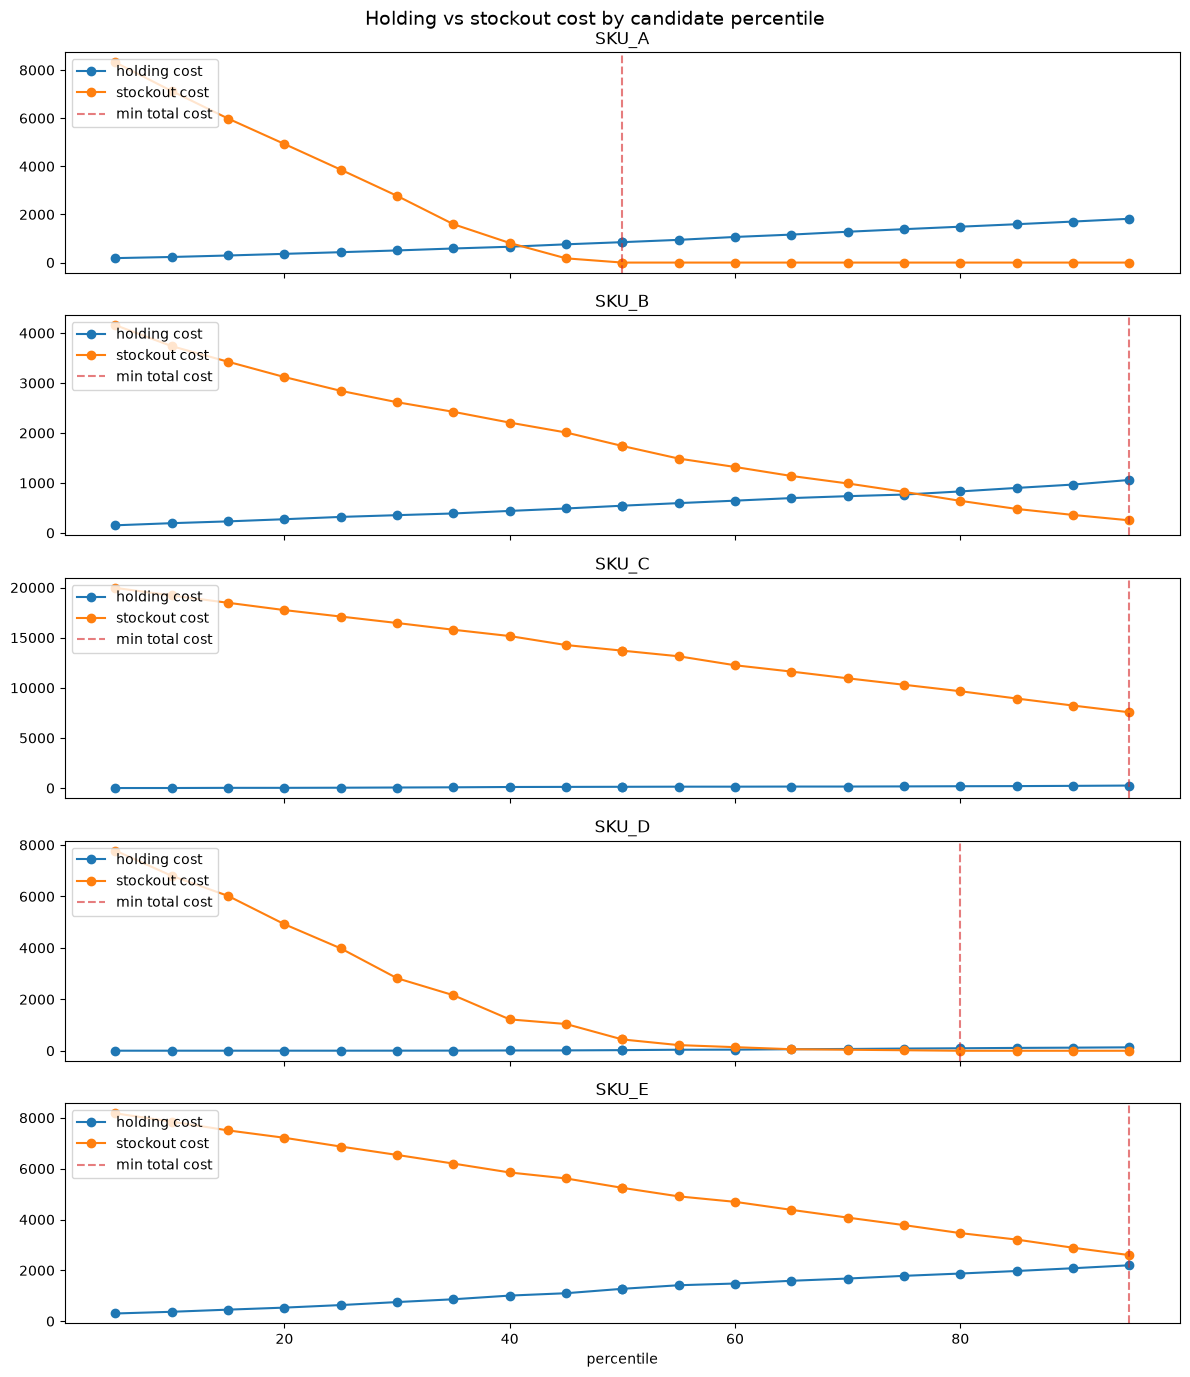

In [8]:
def _target_order_key(value: object) -> float:
    if isinstance(value, str) and value.lower() == "mean":
        return 50.0
    text = str(value)
    if text.startswith("p"):
        digits = "".join(ch for ch in text[1:] if ch.isdigit())
        if digits:
            return float(digits)
    return float(text)

plot_costs_df = debug_df.copy()
plot_costs_df["target_order"] = plot_costs_df["target"].map(_target_order_key)

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 14), sharex=True)
for ax, unique_id in zip(axes, sorted(plot_costs_df["unique_id"].unique()), strict=False):
    d = plot_costs_df.loc[plot_costs_df["unique_id"] == unique_id].sort_values("target_order")
    ax.plot(d["target_order"], d["holding_cost"], marker="o", label="holding cost")
    ax.plot(d["target_order"], d["stockout_cost"], marker="o", label="stockout cost")
    best_row = d.loc[d["total_cost"].idxmin()]
    ax.axvline(best_row["target_order"], color="tab:red", linestyle="--", alpha=0.6, label="min total cost")
    ax.set_title(unique_id)
    ax.legend(loc="upper left")
axes[-1].set_xlabel("percentile")
fig.suptitle("Holding vs stockout cost by candidate percentile", fontsize=14)
fig.tight_layout()
plt.show()

## 8) Pick the best target per item (minimum backtest cost)

In [9]:
best_target_df = (
    debug_df.loc[debug_df.groupby("unique_id")["total_cost"].idxmin()]
    .rename(columns={"total_cost": "backtest_total_cost", "target": "best_target"})
    .sort_values("unique_id")
    .reset_index(drop=True)
)
best_targets = dict(zip(best_target_df["unique_id"], best_target_df["best_target"]))
best_target_df[["unique_id", "best_target", "backtest_total_cost"]]

,unique_id,best_target,backtest_total_cost
0,SKU_A,p50,1145.4
1,SKU_B,p95,1527.6
2,SKU_C,p95,8192.0
3,SKU_D,p80,577.0
4,SKU_E,p95,5059.4


## 9) Simulate the replenishment period with the optimized target per item

Now we apply the best percentile per SKU to the forecast period and run a forward
simulation to see the replenishment decisions and outcomes.

In [10]:
decision_rows = []
summary_rows = []
for unique_id, article_forecast in forecast_by_article.items():
    cfg = ITEM_CONFIG[unique_id]
    chosen_target = best_targets[unique_id]
    policy = _policy_for(chosen_target, article_forecast, cfg["lead_time"], cfg["review_period"], cfg["forecast_horizon"])
    simulation = simulate_replenishment(
        periods=len(article_forecast), demand=[r.demand for r in article_forecast],
        initial_on_hand=cfg["current_stock"], lead_time=cfg["lead_time"], policy=policy,
        holding_cost_per_unit=cfg["holding_cost_per_unit"], stockout_cost_per_unit=cfg["stockout_cost_per_unit"],
        order_cost_per_order=cfg["order_cost_per_order"],
    )
    summary_rows.append({
        "unique_id": unique_id, "best_target": chosen_target,
        "eval_total_cost": simulation.summary.total_cost, "eval_holding_cost": simulation.summary.holding_cost,
        "eval_stockout_cost": simulation.summary.stockout_cost, "eval_ordering_cost": simulation.summary.ordering_cost,
        "total_backorders": simulation.summary.total_backorders,
    })
    for row, snapshot in zip(article_forecast, simulation.snapshots):
        decision_rows.append(ReplenishmentDecisionRow(
            unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
            demand=snapshot.demand, incoming_stock=snapshot.received,
            starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
            on_order=snapshot.on_order, backorders=snapshot.backorders, percentile_target=chosen_target,
        ))

summary_df = pd.DataFrame(summary_rows).sort_values("unique_id")
decision_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
summary_df

,unique_id,best_target,eval_total_cost,eval_holding_cost,eval_stockout_cost,eval_ordering_cost,total_backorders
0,SKU_A,p50,288.45,233.45,0.0,55.0,0
1,SKU_B,p95,368.80,274.80,54.0,40.0,9
2,SKU_C,p95,2348.30,51.30,2240.0,57.0,160
3,SKU_D,p80,129.25,45.25,0.0,84.0,0
4,SKU_E,p95,1173.60,446.60,675.0,52.0,135


## 10) Plot replenishment decisions for each SKU

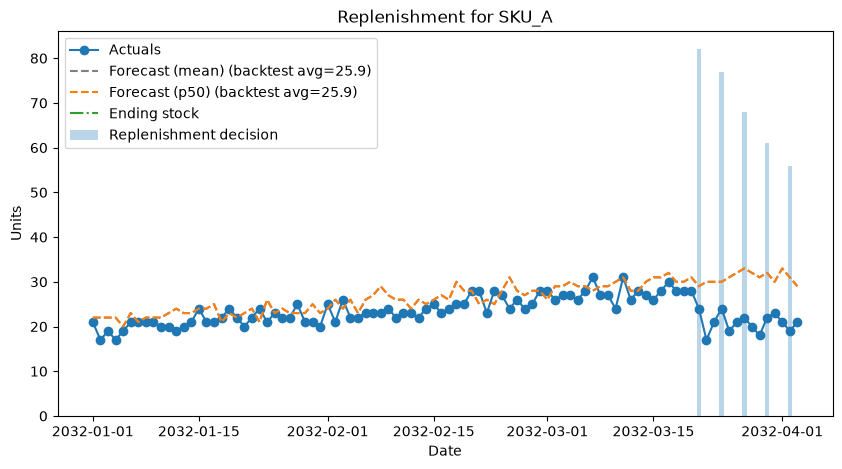

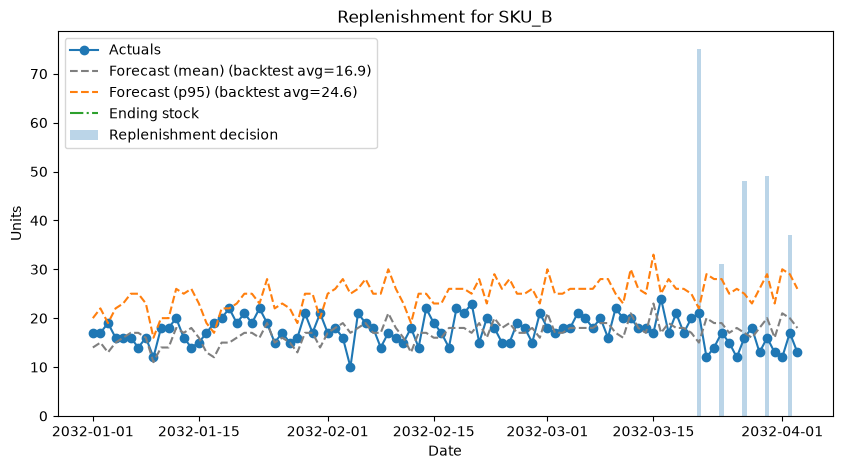

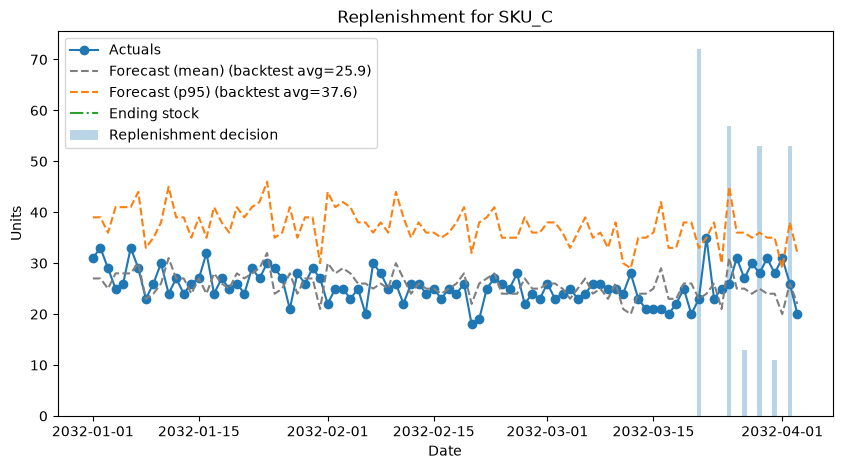

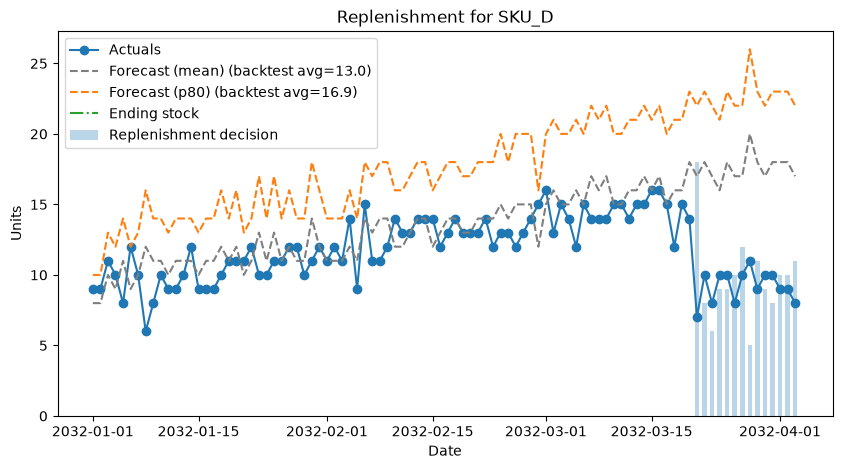

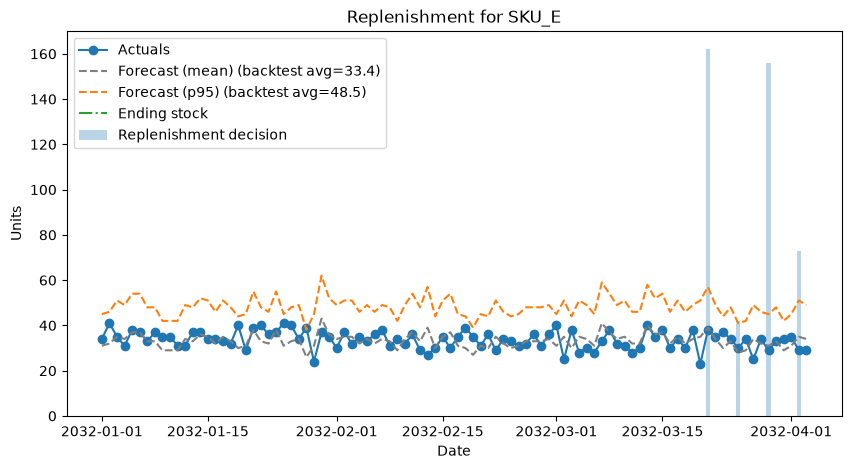

In [11]:
for unique_id in sorted(decision_df["unique_id"].unique()):
    plot_replenishment_decisions(rows_df, decision_df, unique_id=unique_id)